# Entrenamiento, Evaluación y Calibración — Predicción y Riesgo de ACV

Continuación de `eda.ipynb`. Partimos de `preprocessed.pkl`, que ya contiene `X_train_final`/`y_train_final` (balanceado con SMOTE) y `X_test_final`/`y_test_final` (con la proporción real de clases, sin tocar).

Pasos: <br>
**1:** Cargar los datos preprocesados ·  <br>
**2:** baseline basado en `age` y `bmi` · <br>
**3:** ajuste de hiperparámetros y comparación de los 4 modelos de la materia (Regresión Logística, Árbol CART, Random Forest, Gradient Boosting) · <br>
**4:** métricas según el costo del error · <br>
**5:** calibración de probabilidades · <br>
**6:** conclusiones.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

## 1) Cargar los datos preprocesados

In [2]:
RANDOM_STATE = 42
data = pd.read_pickle("../data/preprocessed.pkl")

X_train_final = data["X_train_final"]
y_train_final = data["y_train_final"]
X_test_final = data["X_test_final"]
y_test_final = data["y_test_final"]

print("Train:", X_train_final.shape, "| balance:", y_train_final.value_counts(normalize=True).round(3).to_dict())
print("Test: ", X_test_final.shape, "| balance:", y_test_final.value_counts(normalize=True).round(3).to_dict())

Train: (7498, 12) | balance: {0: 0.5, 1: 0.5}
Test:  (980, 12) | balance: {0: 0.957, 1: 0.043}


## 2) Baseline: función basada en edad y BMI

Piso de comparación para evaluar los modelos. Usamos una única función simple que sólo mira `age` y `bmi` del dataset. Normaliza ambas columnas con el mínimo y el máximo del propio train y devuelve un score de riesgo entre 0 y 1 (promedio de las dos), sin ajustar pesos ni parámetros.

In [3]:
class AgeBmiBaseline:
    """
    Baseline: combina `age` y `bmi` (normalizados con el min/max del train)
    en un score de riesgo entre 0 y 1.
    """
    def __init__(self, age_col="age", bmi_col="bmi"):
        self.age_col = age_col
        self.bmi_col = bmi_col

    def fit(self, X, y=None):
        self.age_min_, self.age_max_ = X[self.age_col].min(), X[self.age_col].max()
        self.bmi_min_, self.bmi_max_ = X[self.bmi_col].min(), X[self.bmi_col].max()
        return self

    def _risk_score(self, X):
        age_norm = (X[self.age_col] - self.age_min_) / (self.age_max_ - self.age_min_)
        bmi_norm = (X[self.bmi_col] - self.bmi_min_) / (self.bmi_max_ - self.bmi_min_)
        return ((age_norm + bmi_norm) / 2).clip(0, 1).to_numpy()

    def predict_proba(self, X):
        score = self._risk_score(X)
        return np.column_stack([1 - score, score])

    def predict(self, X):
        return (self._risk_score(X) >= 0.5).astype(int)


baseline_age_bmi = AgeBmiBaseline()
baseline_age_bmi.fit(X_train_final, y_train_final)

### Función de evaluación

Reunimos las métricas que importan con desbalance: `recall`, `precision`, `f1`, `balanced_accuracy` (alternativa honesta al accuracy) y `roc_auc`. La misma función sirve tanto para el baseline como para los modelos entrenados.

In [4]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred
    return {
        "modelo": name,
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results = [
    evaluate_model("Baseline (edad + BMI)", baseline_age_bmi, X_test_final, y_test_final),
]

## 3) Ajuste de hiperparámetros y comparación de modelos

Nos quedamos con 4 modelos de la materia: Regresión Logística (lineal, interpretable), Árbol CART (Clase 4) y dos ensambles (Clase 5) — Random Forest (bagging) y Gradient Boosting (boosting), señalado en el resumen como el que suele rendir mejor en datos tabulares. A cada uno le aplicamos `GridSearchCV` con `StratifiedKFold` sobre el train (ya balanceado) antes de evaluarlo en el test, para comparar siempre la mejor versión de cada modelo. Optimizamos por `recall` porque, en un score de riesgo de ACV, un falso negativo (no detectar un ACV) suele costar más que un falso positivo.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Regresión Logística": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Árbol CART": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 5, 10, None], "min_samples_leaf": [1, 5, 10, 20], "criterion": ["gini", "entropy"]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [100, 300], "max_depth": [None, 10, 20], "max_features": ["sqrt", "log2"]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
    ),
}

tuned_models = {}
for name, (estimator, grid) in param_grids.items():
    search = GridSearchCV(estimator, param_grid=grid, scoring="recall", cv=cv, n_jobs=-1)
    search.fit(X_train_final, y_train_final)
    tuned_models[name] = search.best_estimator_
    print(f"{name} — mejores parámetros: {search.best_params_} | Recall (cv): {search.best_score_:.3f}")
    results.append(evaluate_model(name, search.best_estimator_, X_test_final, y_test_final))

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

Regresión Logística — mejores parámetros: {'C': 0.01} | Recall (cv): 0.825
Árbol CART — mejores parámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1} | Recall (cv): 0.952
Random Forest — mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300} | Recall (cv): 0.973
Gradient Boosting — mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} | Recall (cv): 0.928


,modelo,recall,precision,f1,balanced_accuracy,roc_auc
0,Regresión Logística,0.809524,0.142857,0.242857,0.796020,0.875622
1,Regresión Logística,0.809524,0.143460,0.243728,0.796553,0.870342
2,Baseline (edad + BMI),0.928571,0.092417,0.168103,0.760128,0.844604
3,Random Forest,0.071429,0.142857,0.095238,0.526119,0.824640
4,Random Forest,0.071429,0.150000,0.096774,0.526652,0.821251
5,Gradient Boosting,0.071429,0.136364,0.093750,0.525586,0.791984
6,Gradient Boosting,0.071429,0.136364,0.093750,0.525586,0.791984
7,Árbol CART,0.190476,0.101266,0.132231,0.557392,0.557392
8,Árbol CART,0.142857,0.082192,0.104348,0.535714,0.535714


### Antes de elegir: el umbral 0.5 no es comparable entre modelos

`recall`/`precision`/`f1` de la tabla anterior salen de `.predict()`, que usa un umbral fijo de 0.5. Ese umbral tiene sentido para un modelo entrenado y evaluado con la misma proporción de clases — pero acá entrenamos con train balanceado 50/50 (SMOTE) y evaluamos sobre test con la proporción real (~5%). Para los ensambles esto corre sus probabilidades y castiga el recall a un umbral que no fue pensado para ellos, aunque su capacidad de ranking (ROC-AUC) sea competitiva. Antes de descartar un modelo por bajo recall, conviene mirar su curva Precision-Recall completa, no solo el punto en 0.5.

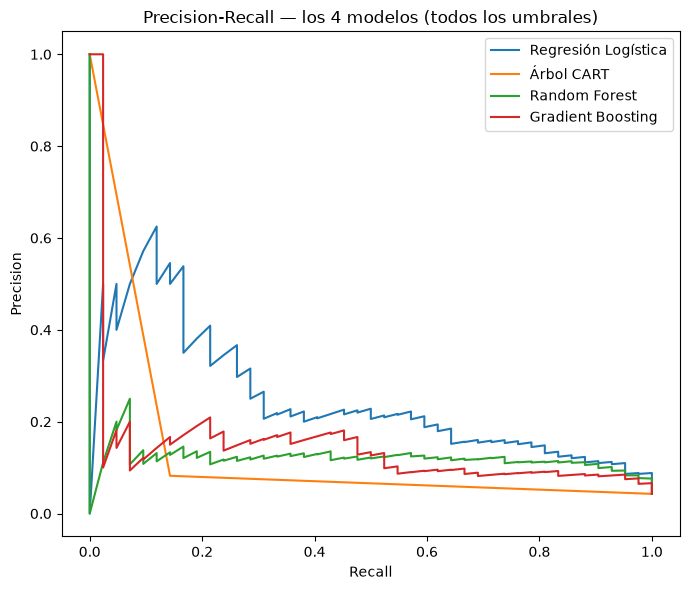

In [7]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in tuned_models.items():
    proba = model.predict_proba(X_test_final)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_final, proba)
    ax.plot(rec, prec, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — los 4 modelos (todos los umbrales)")
ax.legend()
plt.tight_layout()
plt.show()

### Umbral óptimo por modelo (en vez de 0.5 fijo)

Para cada modelo, buscamos el umbral que maximiza F1 en el test, así comparamos a cada uno en su mejor punto de operación posible, no en un umbral arbitrario que puede favorecer a unos por accidente. 

In [8]:
def best_threshold_report(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, proba)
    f1_scores = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) != 0)
    best_idx = np.argmax(f1_scores[:-1])  # el último punto no tiene umbral asociado
    return {
        "modelo": name,
        "umbral_optimo": thresh[best_idx],
        "precision": prec[best_idx],
        "recall": rec[best_idx],
        "f1": f1_scores[best_idx],
    }

threshold_df = pd.DataFrame([
    best_threshold_report(name, model, X_test_final, y_test_final)
    for name, model in tuned_models.items()
]).sort_values("f1", ascending=False).reset_index(drop=True)
threshold_df

,modelo,umbral_optimo,precision,recall,f1
0,Regresión Logística,0.714846,0.222222,0.571429,0.320000
1,Gradient Boosting,0.268850,0.180952,0.452381,0.258503
2,Random Forest,0.175000,0.131868,0.571429,0.214286
3,Árbol CART,1.000000,0.082192,0.142857,0.104348


## 4) Métricas de los 4 modelos

Con la tabla de umbrales óptimos a la vista, graficamos matriz de confusión, curva ROC y curva Precision-Recall de los 4 modelos para poder comparar visualmente. Queda calculado `best_name` (el modelo con mayor F1 en su umbral óptimo, priorizando recall por sobre F1, por ejemplo, para no perder ACV reales aunque cueste mas precisión) solo a modo de referencia: la calibración de probabilidades de la sección 5 se aplica a los 4 modelos, no unicamente a este.

In [9]:
best_name = threshold_df.iloc[0]["modelo"]
best_model = tuned_models[best_name]
best_threshold = threshold_df.iloc[0]["umbral_optimo"]
print("Mejor modelo (mayor F1 en su umbral óptimo):", best_name, "| umbral óptimo:", round(best_threshold, 3))

Mejor modelo (mayor F1 en su umbral óptimo): Regresión Logística | umbral óptimo: 0.715


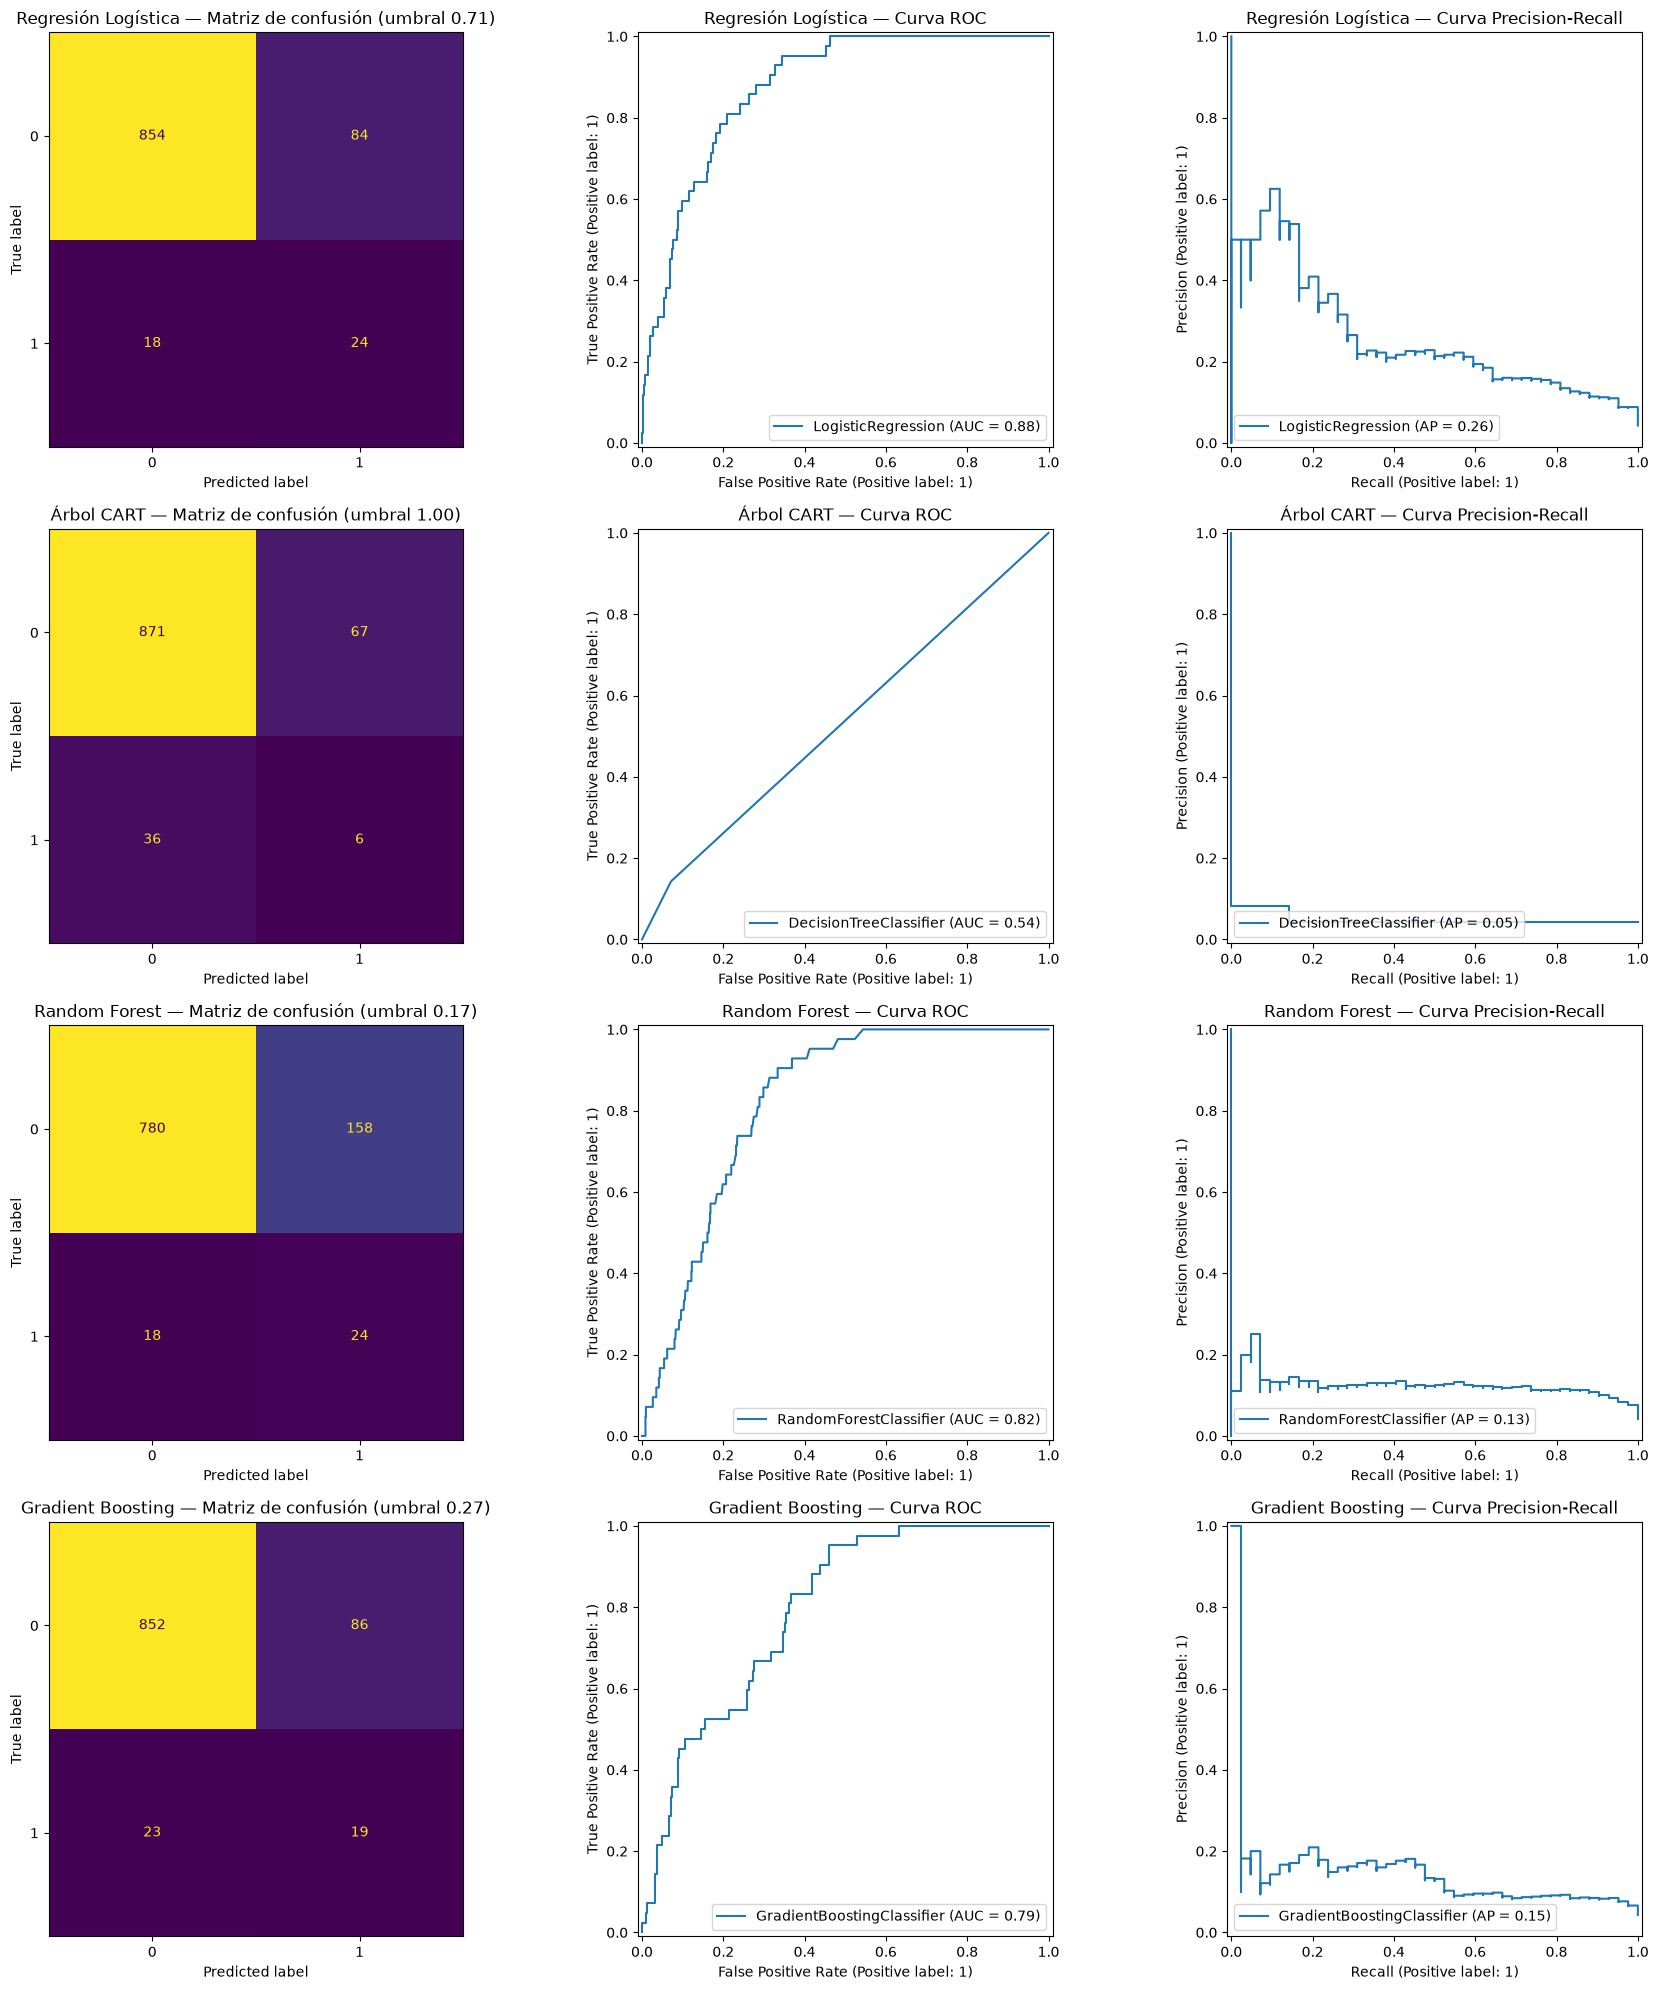

In [10]:
threshold_by_model = threshold_df.set_index("modelo")["umbral_optimo"]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for row, (name, model) in enumerate(tuned_models.items()):
    threshold = threshold_by_model[name]
    proba = model.predict_proba(X_test_final)[:, 1]
    y_pred_model = (proba >= threshold).astype(int)

    cm = confusion_matrix(y_test_final, y_pred_model)
    ConfusionMatrixDisplay(cm).plot(ax=axes[row, 0], colorbar=False)
    axes[row, 0].set_title(f"{name} — Matriz de confusión (umbral {threshold:.2f})")

    RocCurveDisplay.from_estimator(model, X_test_final, y_test_final, ax=axes[row, 1])
    axes[row, 1].set_title(f"{name} — Curva ROC")

    PrecisionRecallDisplay.from_estimator(model, X_test_final, y_test_final, ax=axes[row, 2])
    axes[row, 2].set_title(f"{name} — Curva Precision-Recall")

plt.tight_layout()
plt.show()

## 5) Calibración de probabilidades

Necesaria acá por dos motivos: el proyecto entrega un score de riesgo (no solo una clase), y entrenamos con `SMOTE`. Esto es un error de calibración: balancear para entrenar y no corregir la tasa base real deja las probabilidades infladas respecto a la prevalencia real (~5%, no 50%).

Para corregirlo sin volver a tocar el test dos veces, partimos `X_test_final` (que conserva la proporción real) en dos mitades estratificadas: una para calibrar el mapeo de probabilidades y otra, separada, para la evaluación final. Calibramos los 4 modelos usando la misma partición `X_calib`/`X_eval`, para poder comparar el efecto de la calibración modelo por modelo.

In [11]:
X_calib, X_eval, y_calib, y_eval = train_test_split(
    X_test_final, y_test_final, test_size=0.5, stratify=y_test_final, random_state=RANDOM_STATE
)

calibration_results = {}

for name, model in tuned_models.items():
    proba_before = model.predict_proba(X_eval)[:, 1]
    brier_before = brier_score_loss(y_eval, proba_before)
    frac_pos_before, mean_pred_before = calibration_curve(y_eval, proba_before, n_bins=10, strategy="quantile")

    calibrated_model = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
    calibrated_model.fit(X_calib, y_calib)

    proba_after = calibrated_model.predict_proba(X_eval)[:, 1]
    brier_after = brier_score_loss(y_eval, proba_after)
    frac_pos_after, mean_pred_after = calibration_curve(y_eval, proba_after, n_bins=10, strategy="quantile")

    calibration_results[name] = {
        "modelo_calibrado": calibrated_model,
        "brier_before": brier_before,
        "brier_after": brier_after,
        "frac_pos_before": frac_pos_before,
        "mean_pred_before": mean_pred_before,
        "frac_pos_after": frac_pos_after,
        "mean_pred_after": mean_pred_after,
    }

brier_df = pd.DataFrame([
    {"modelo": name, "brier_antes": r["brier_before"], "brier_despues": r["brier_after"]}
    for name, r in calibration_results.items()
]).sort_values("brier_despues").reset_index(drop=True)
brier_df

,modelo,brier_antes,brier_despues
0,Regresión Logística,0.144970,0.037687
1,Gradient Boosting,0.050025,0.038673
2,Random Forest,0.049547,0.040073
3,Árbol CART,0.095918,0.040872


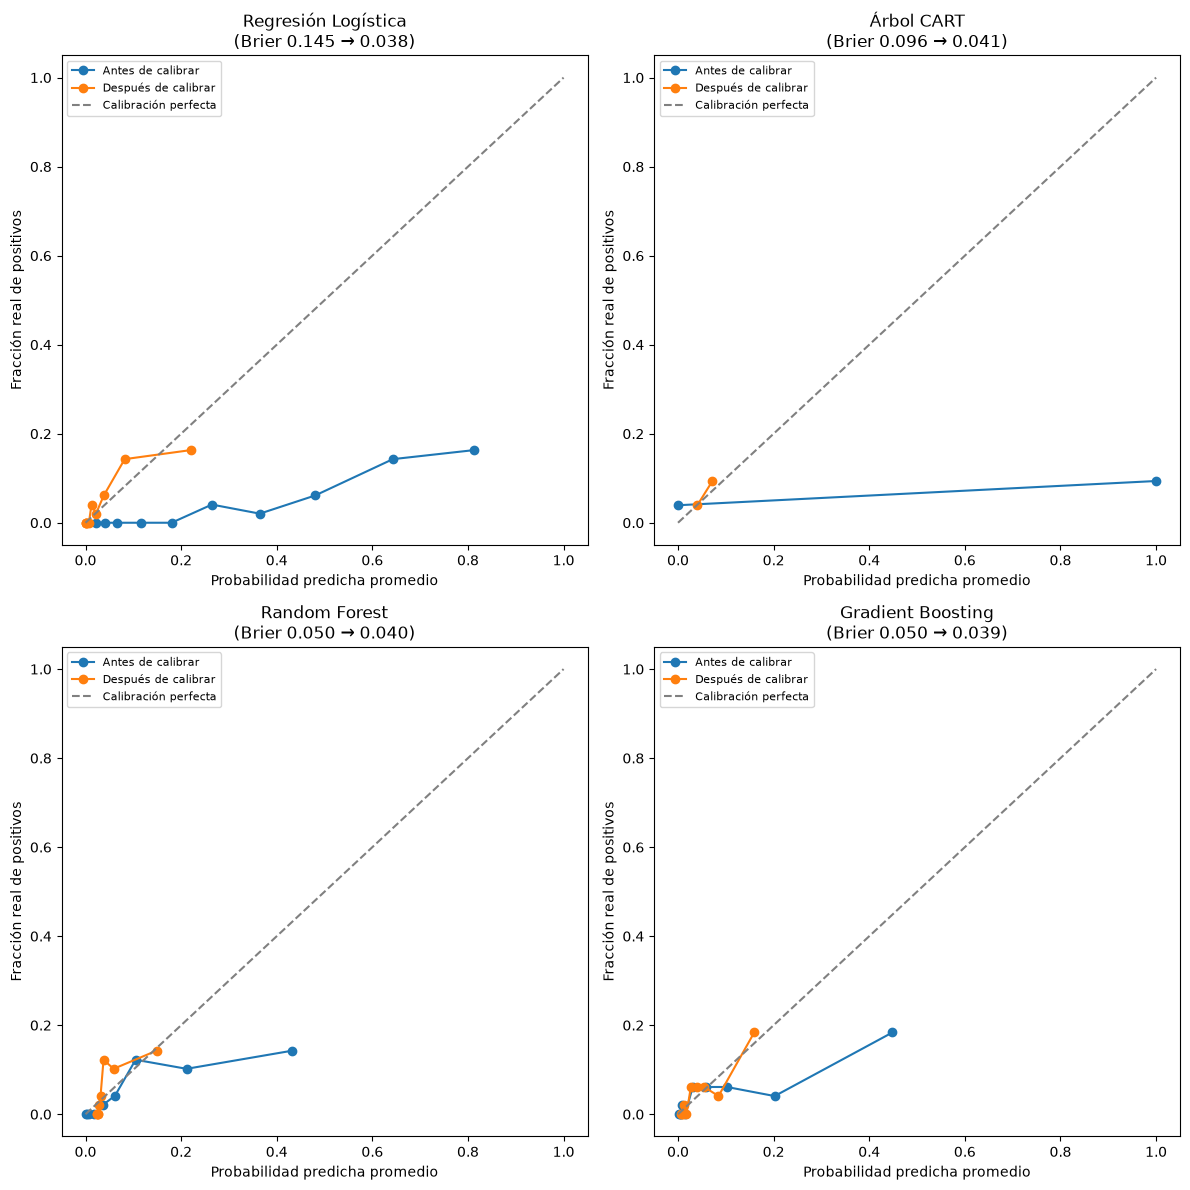

method='sigmoid' (Platt) recomendado por el tamaño de muestra;
probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (name, r) in zip(axes.ravel(), calibration_results.items()):
    ax.plot(r["mean_pred_before"], r["frac_pos_before"], marker="o", label="Antes de calibrar")
    ax.plot(r["mean_pred_after"], r["frac_pos_after"], marker="o", label="Después de calibrar")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
    ax.set_xlabel("Probabilidad predicha promedio")
    ax.set_ylabel("Fracción real de positivos")
    ax.set_title(f"{name}\n(Brier {r['brier_before']:.3f} → {r['brier_after']:.3f})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("method='sigmoid' (Platt) recomendado por el tamaño de muestra;")
print("probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.")

## 6) Conclusiones